In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Asus\Documents\prj\Fraud-GNN-Detection\data\creditcard.csv")

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from sklearn.neighbors import NearestNeighbors
from torch_geometric.data import Data

# load dataset
df = pd.read_csv(r"C:\Users\Asus\Documents\prj\Fraud-GNN-Detection\data\creditcard.csv")

# features & label
X = df.drop("Class", axis=1)
y = df["Class"]

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# convert to tensor
x = torch.tensor(X_scaled, dtype=torch.float)
y = torch.tensor(y.values, dtype=torch.long)

# build graph (NO .toarray())
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_scaled)

edges = knn.kneighbors_graph(X_scaled)

row, col = edges.nonzero()
edge_index = torch.tensor([row, col], dtype=torch.long)

# create data object
data = Data(x=x, edge_index=edge_index, y=y)

print(data)

Data(x=[284807, 30], edge_index=[2, 1424035], y=[284807])


C:\Users\Asus\AppData\Local\Temp\ipykernel_7368\715556445.py:29: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  edge_index = torch.tensor([row, col], dtype=torch.long)


🔹 2 Train/Test Split

In [3]:
from sklearn.model_selection import train_test_split

indices = torch.arange(data.num_nodes)

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=data.y,
    random_state=42
)

data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)

data.train_mask[train_idx] = True
data.test_mask[test_idx] = True

🔹 3. Define Model

In [4]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        
        x = self.conv2(x, edge_index)
        
        return F.log_softmax(x, dim=1)

🔹 4. Initialize Model

In [5]:
import torch.optim as optim

model = GCN(data.num_features, 32)

# class imbalance handling
class_counts = torch.bincount(data.y)
weights = 1.0 / class_counts.float()
weights = weights / weights.sum()

criterion = torch.nn.NLLLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.01)

🔹 5. Train Model

In [6]:
for epoch in range(30):
    model.train()
    optimizer.zero_grad()
    
    out = model(data)
    
    loss = criterion(
        out[data.train_mask],
        data.y[data.train_mask]
    )
    
    loss.backward()
    optimizer.step()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 0.8541
Epoch 5, Loss: 0.3254
Epoch 10, Loss: 0.2093
Epoch 15, Loss: 0.1677
Epoch 20, Loss: 0.1484
Epoch 25, Loss: 0.1353


🔹 6. Evaluate Model

In [7]:
from sklearn.metrics import roc_auc_score, average_precision_score

model.eval()

with torch.no_grad():
    output = model(data)
    probs = torch.exp(output)[:, 1]  # convert log_softmax → probability

roc = roc_auc_score(
    data.y[data.test_mask].cpu(),
    probs[data.test_mask].cpu()
)

pr = average_precision_score(
    data.y[data.test_mask].cpu(),
    probs[data.test_mask].cpu()
)

print("GCN ROC-AUC:", roc)
print("GCN PR-AUC:", pr)

GCN ROC-AUC: 0.9753086131751518
GCN PR-AUC: 0.6384142183097216


| Transaction | Fraud Probability |
| ----------- | ----------------- |
| T1          | 0.01 (Safe)       |
| T2          | 0.87 (Fraud)      |
| T3          | 0.45 (Suspicious) |


In [8]:
import pandas as pd

results = pd.DataFrame({
    "Actual": data.y.cpu().numpy(),
    "Fraud_Probability": probs.cpu().numpy()
})

print(results.head(10))

   Actual  Fraud_Probability
0       0           0.078274
1       0           0.032619
2       0           0.190606
3       0           0.010067
4       0           0.129484
5       0           0.050697
6       0           0.179164
7       0           0.462858
8       0           0.017691
9       0           0.073678


📊 ✅ FINAL OUTPUT REPORT


🔹 1. Create Final Results Table

In [13]:
import pandas as pd

# load original dataset
df = pd.read_csv(r"C:\Users\Asus\Documents\prj\Fraud-GNN-Detection\data\creditcard.csv")

# create results
results = pd.DataFrame({
    "Transaction_ID": range(len(data.y)),
    "Actual": data.y.cpu().numpy(),
    "Fraud_Probability": probs.cpu().numpy()
})

# add useful columns
results["Time"] = df["Time"]
results["Amount"] = df["Amount"]

# create prediction using threshold
threshold = 0.5
results["Prediction"] = (results["Fraud_Probability"] > threshold).astype(int)



print(results.head())

   Transaction_ID  Actual  Fraud_Probability  Time  Amount  Prediction
0               0       0           0.078274   0.0  149.62           0
1               1       0           0.032619   0.0    2.69           0
2               2       0           0.190606   1.0  378.66           0
3               3       0           0.010067   1.0  123.50           0
4               4       0           0.129484   2.0   69.99           0


🔹 2. Show Top Suspicious Transactions 

In [14]:

top_fraud = results.sort_values(by="Fraud_Probability", ascending=False).head(10)

print(top_fraud)

        Transaction_ID  Actual  Fraud_Probability      Time   Amount  \
27749            27749       1                1.0   34687.0    19.02   
11343            11343       1                1.0   19762.0     1.00   
102441          102441       1                1.0   68207.0     1.00   
10897            10897       1                1.0   18690.0     1.00   
10906            10906       0                1.0   18709.0    89.99   
41943            41943       1                1.0   40892.0     0.76   
252124          252124       1                1.0  155662.0     0.77   
252774          252774       1                1.0  155965.0     0.77   
23128            23128       0                1.0   32605.0  7429.15   
42473            42473       1                1.0   41116.0     3.79   

        Prediction  
27749            1  
11343            1  
102441           1  
10897            1  
10906            1  
41943            1  
252124           1  
252774           1  
23128            1

🔹 3. Model Performance Summary

In [15]:

from sklearn.metrics import classification_report

print(classification_report(results["Actual"], results["Prediction"]))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    284315
           1       0.06      0.92      0.12       492

    accuracy                           0.98    284807
   macro avg       0.53      0.95      0.55    284807
weighted avg       1.00      0.98      0.99    284807



🔹 4. Confusion Matrix

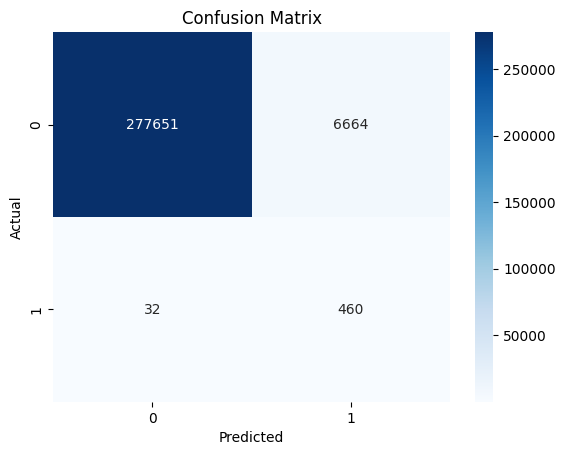

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(results["Actual"], results["Prediction"])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

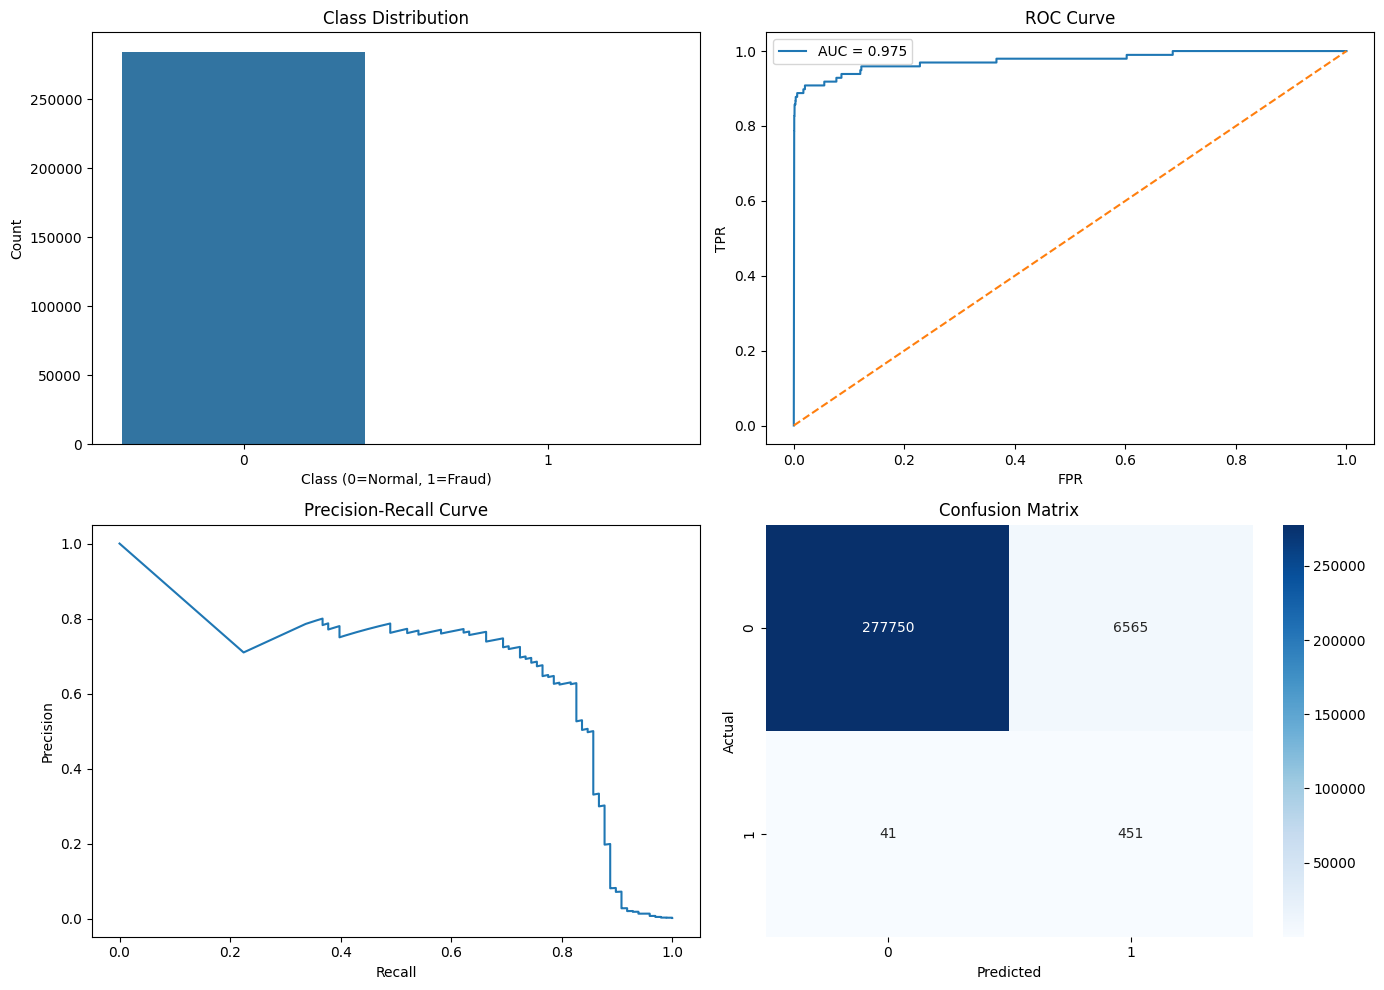

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, auc

plt.figure(figsize=(14, 10))

# 🔹 1. Class Distribution
plt.subplot(2, 2, 1)
sns.countplot(x=data.y.cpu().numpy())
plt.title("Class Distribution")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")

# 🔹 2. ROC Curve
plt.subplot(2, 2, 2)
fpr, tpr, _ = roc_curve(
    data.y[data.test_mask].cpu(),
    probs[data.test_mask].cpu()
)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

# 🔹 3. Precision-Recall Curve
plt.subplot(2, 2, 3)
precision, recall, _ = precision_recall_curve(
    data.y[data.test_mask].cpu(),
    probs[data.test_mask].cpu()
)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")

# 🔹 4. Confusion Matrix
plt.subplot(2, 2, 4)
cm = confusion_matrix(results["Actual"], results["Prediction"])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
results.to_csv("fraud_detection_results.csv", index=False)
print("Report saved successfully ✅")

Report saved successfully ✅
